# SciFact Benchmark on Colab

This notebook runs the ScholarRAG SciFact bi-encoder benchmark on Google Colab with per-model isolation, live logs, and incremental result collection.

It evaluates `query -> abstract` retrieval over the SciFact test set: `300` unique queries over `5,183` abstracts.

## L4 inference setup

This notebook defaults to an `L4` GPU profile because we are benchmarking inference, not training.

The benchmark now mixes small and large bi-encoders so you can compare retrieval quality against latency:

- `BGE-EN-ICL` plain
- `BGE-EN-ICL` with few-shot examples
- `Qwen3-Embedding-0.6B`
- `Qwen3-Embedding-4B`
- `Qwen3-Embedding-8B`
- `Harrier OSS 0.6B`
- `EmbeddingGemma 300M` default
- `EmbeddingGemma 300M` fact-check prompt
- `EmbeddingGemma 300M` QA prompt
- `SPECTER2`

`EmbeddingGemma 300M` is gated on Hugging Face, so this notebook reads `HF_TOKEN` from the environment or a one-cell override below.

The result files include both quality metrics and latency metrics, plus direct `nDCG@10`, `MRR@10`, and `MAP@10` comparison plots and a quality-vs-latency tradeoff plot.


In [1]:
# Optional: clone the repo only if you want a fresh remote checkout.
# Do not run this if you already uploaded or mounted an updated local copy.
!rm -rf /content/ScholarRAG
!git clone https://github.com/Wasiq-Malik/ScholarRAG.git /content/ScholarRAG


Cloning into '/content/ScholarRAG'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 59 (delta 28), reused 51 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 45.36 KiB | 1.81 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [2]:
%cd /content/ScholarRAG

!python -m pip install -U pip
!pip install -e .

/content/ScholarRAG
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Obtaining file:///content/ScholarRAG
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 157.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.4 MB/s  0:00:00
  Building editable for scholarrag (pyproject.toml) ... done
  Created wheel for scholarrag: filename=scholarrag-0.1.0-0.editable-py3-none-any.whl size=3189 sha256=8f11bc8f8cb7c79c766d1ebf49facd6389fd9870fa438242703b4c130c15316f
  Stored in directory: /tmp/pip-ephem-wheel-cache-0olgdq03/wheels/0a/89/0c/d5413d54f0d9857abad3277dd48a8e9f3f1a399dd033320dd6
Succe

In [3]:
!nvidia-smi || true


Tue Apr 28 22:54:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from datetime import datetime
from pathlib import Path
import json
import os

# Optional: paste a Hugging Face token for gated models in this session only.
# Leave blank if HF_TOKEN is already set in Colab secrets or the environment.
HF_TOKEN = os.environ.get("HF_TOKEN", "")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
else:
    print("HF_TOKEN is not set. EmbeddingGemma variants will fail until you provide it.")

RUN_NAME = f"colab_scifact_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = Path("benchmarks/scifact/results") / RUN_NAME

MODELS = [
    "bge_en_icl_plain",
    "bge_en_icl_examples",
    "qwen3_0_6b",
    "qwen3_4b",
    "qwen3_8b",
    "harrier_0_6b",
    "embeddinggemma_300m",
    "embeddinggemma_fact_check",
    "embeddinggemma_qa",
    "specter2",
]

DOCUMENT_MODE = "abstract"
SPLIT = "test"
TOP_K = 100
MAX_QUERIES = None
DEVICE = "cuda"
DTYPE = "auto"

GPU_PRESETS = {
    "l4_default": {
        "bge_en_icl_plain": 4,
        "bge_en_icl_examples": 4,
        "qwen3_0_6b": 32,
        "qwen3_4b": 8,
        "qwen3_8b": 4,
        "harrier_0_6b": 64,
        "embeddinggemma_300m": 128,
        "embeddinggemma_fact_check": 128,
        "embeddinggemma_qa": 128,
        "specter2": 128,
    },
    "l4_conservative": {
        "bge_en_icl_plain": 1,
        "bge_en_icl_examples": 1,
        "qwen3_0_6b": 8,
        "qwen3_4b": 2,
        "qwen3_8b": 1,
        "harrier_0_6b": 16,
        "embeddinggemma_300m": 32,
        "embeddinggemma_fact_check": 32,
        "embeddinggemma_qa": 32,
        "specter2": 32,
    },
}

GPU_PRESET = "l4_default"
BATCH_SIZE_OVERRIDES = dict(GPU_PRESETS[GPU_PRESET])

# Optional fine-grained overrides after loading the preset.
# Example: BATCH_SIZE_OVERRIDES['qwen3_8b'] = 1

print(json.dumps({
    "output_dir": str(OUTPUT_DIR),
    "models": MODELS,
    "split": SPLIT,
    "document_mode": DOCUMENT_MODE,
    "device": DEVICE,
    "dtype": DTYPE,
    "top_k": TOP_K,
    "max_queries": MAX_QUERIES,
    "gpu_preset": GPU_PRESET,
    "batch_size_overrides": BATCH_SIZE_OVERRIDES,
    "hf_token_set": bool(os.environ.get("HF_TOKEN")),
}, indent=2))


{
  "output_dir": "benchmarks/scifact/results/colab_scifact_20260428_225430",
  "models": [
    "bge_en_icl_plain",
    "bge_en_icl_examples",
    "qwen3_0_6b",
    "qwen3_4b",
    "qwen3_8b",
    "harrier_0_6b",
    "embeddinggemma_300m",
    "embeddinggemma_fact_check",
    "embeddinggemma_qa",
    "specter2"
  ],
  "split": "test",
  "document_mode": "abstract",
  "device": "cuda",
  "dtype": "auto",
  "top_k": 100,
  "max_queries": null,
  "gpu_preset": "l4_default",
  "batch_size_overrides": {
    "bge_en_icl_plain": 4,
    "bge_en_icl_examples": 4,
    "qwen3_0_6b": 32,
    "qwen3_4b": 8,
    "qwen3_8b": 4,
    "harrier_0_6b": 64,
    "embeddinggemma_300m": 128,
    "embeddinggemma_fact_check": 128,
    "embeddinggemma_qa": 128,
    "specter2": 128
  },
  "hf_token_set": true
}


In [5]:
from benchmarks.scifact.models import available_model_keys

registered_models = available_model_keys()
print("Registered benchmark models:", registered_models)
missing = sorted(set(MODELS) - set(registered_models))
if missing:
    raise ValueError(f"Notebook model list is not supported by the checked-out code: {missing}")


Registered benchmark models: ['bge_en_icl_plain', 'bge_en_icl_examples', 'qwen3_0_6b', 'qwen3_4b', 'qwen3_8b', 'harrier_0_6b', 'embeddinggemma_300m', 'embeddinggemma_fact_check', 'embeddinggemma_qa', 'specter2']


## Preset guidance

- Start with `l4_default`.
- The three EmbeddingGemma variants should be cheap relative to the 4B and 8B models.
- Use `l4_conservative` only if one of the larger models is unstable.
- If only one model needs adjustment, keep the main preset and reduce only that model in `BATCH_SIZE_OVERRIDES`.


In [6]:
import json
import os
import shlex
import signal
import subprocess
import sys
from pathlib import Path

def run_one_model(model_key: str) -> dict:
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    log_path = model_dir / "run.log"

    cmd = [
        sys.executable,
        "benchmarks/scifact/run_benchmark.py",
        "--split", SPLIT,
        "--document-mode", DOCUMENT_MODE,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--top-k", str(TOP_K),
        "--output-dir", str(model_dir),
        "--models", model_key,
        "--show-progress",
    ]

    if MAX_QUERIES is not None:
        cmd += ["--max-queries", str(MAX_QUERIES)]

    batch_size = BATCH_SIZE_OVERRIDES.get(model_key)
    if batch_size is not None:
        cmd += ["--batch-size", str(batch_size)]

    env = dict(os.environ)
    env["PYTHONUNBUFFERED"] = "1"

    print(f"\n=== Running {model_key} ===")
    print("Command:")
    print(" ".join(shlex.quote(part) for part in cmd))
    print(f"Log file: {log_path}")
    print(f"Configured batch size: {batch_size}")

    with log_path.open("w") as log_handle:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
            log_handle.write(line)
        returncode = process.wait()

    result = {
        "model": model_key,
        "batch_size": batch_size,
        "returncode": returncode,
        "status": "completed" if returncode == 0 else "failed",
        "log_path": str(log_path),
        "output_dir": str(model_dir),
    }

    if returncode == -signal.SIGKILL:
        result["failure_reason"] = "likely_oom_or_os_kill"
    elif returncode != 0:
        result["failure_reason"] = f"nonzero_exit_{returncode}"

    status_path = model_dir / "notebook_status.json"
    status_path.write_text(json.dumps(result, indent=2))
    return result


all_results = []
for model_key in MODELS:
    all_results.append(run_one_model(model_key))

aggregate_status_path = OUTPUT_DIR / "notebook_status.json"
aggregate_status_path.parent.mkdir(parents=True, exist_ok=True)
aggregate_status_path.write_text(json.dumps(all_results, indent=2))
all_results


=== Running bge_en_icl_plain ===
Command:
/usr/bin/python3 benchmarks/scifact/run_benchmark.py --split test --document-mode abstract --device cuda --dtype auto --top-k 100 --output-dir benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_plain --models bge_en_icl_plain --show-progress --batch-size 4
Log file: benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_plain/run.log
Configured batch size: 4

Generating corpus split: 100%|██████████| 5183/5183 [00:00<00:00, 161299.04 examples/s]

Generating queries split: 100%|██████████| 1109/1109 [00:00<00:00, 473770.94 examples/s]

Generating train split: 100%|██████████| 919/919 [00:00<00:00, 118078.83 examples/s]

Generating test split: 100%|██████████| 339/339 [00:00<00:00, 193820.75 examples/s]

=== Benchmarking bge_en_icl_plain (BAAI/bge-en-icl) ===
`torch_dtype` is deprecated! Use `dtype` instead!
2026-04-28 22:55:31.256794: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see 

[{'model': 'bge_en_icl_plain',
  'batch_size': 4,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_plain/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_plain'},
 {'model': 'bge_en_icl_examples',
  'batch_size': 4,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_examples/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_20260428_225430/bge_en_icl_examples'},
 {'model': 'qwen3_0_6b',
  'batch_size': 32,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b'},
 {'model': 'qwen3_4b',
  'batch_size': 8,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_20260

In [7]:
import pandas as pd
from benchmarks.scifact.generate_report import build_report

summary_rows = []
for result in all_results:
    model_dir = Path(result["output_dir"])
    summary_path = model_dir / "summary.csv"
    if summary_path.exists():
        frame = pd.read_csv(summary_path)
        if not frame.empty:
            summary_rows.append(frame)

if summary_rows:
    aggregate_summary = pd.concat(summary_rows, ignore_index=True)
    aggregate_summary = aggregate_summary.sort_values("ndcg_at_10", ascending=False)
    aggregate_summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
    (OUTPUT_DIR / "summary.json").write_text(aggregate_summary.to_json(orient="records", indent=2))

    aggregate_config = {
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
        "device": DEVICE,
        "dtype": DTYPE,
        "models": MODELS,
        "query_count": int(aggregate_summary.iloc[0]["query_count"]),
        "corpus_size": int(aggregate_summary.iloc[0]["corpus_size"]),
        "top_k": TOP_K,
        "gpu_preset": GPU_PRESET,
        "batch_size_overrides": BATCH_SIZE_OVERRIDES,
    }
    (OUTPUT_DIR / "config.json").write_text(json.dumps(aggregate_config, indent=2))
    report_path = build_report(OUTPUT_DIR)
    print(f"Wrote aggregate report to {report_path}")
    aggregate_summary
else:
    print("No successful model runs produced a summary.csv file.")

Wrote aggregate report to benchmarks/scifact/results/colab_scifact_20260428_225430/REPORT.md


In [8]:
import pandas as pd

pd.DataFrame(all_results)

,model,batch_size,returncode,status,log_path,output_dir
0,bge_en_icl_plain,4,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
1,bge_en_icl_examples,4,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
2,qwen3_0_6b,32,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
3,qwen3_4b,8,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
4,qwen3_8b,4,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
5,harrier_0_6b,64,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
6,embeddinggemma_300m,128,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
7,embeddinggemma_fact_check,128,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
8,embeddinggemma_qa,128,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...
9,specter2,128,0,completed,benchmarks/scifact/results/colab_scifact_20260...,benchmarks/scifact/results/colab_scifact_20260...


In [9]:
from IPython.display import Markdown, display

report_path = OUTPUT_DIR / "REPORT.md"
if report_path.exists():
    display(Markdown(report_path.read_text()))
else:
    print("No aggregate report found yet.")

# SciFact Benchmark Report

## Run configuration

- Split: `test`
- Document mode: `abstract`
- Device: `cuda`
- Dtype: `auto`
- Query count: `300`
- Corpus size: `5183`
- Models: `bge_en_icl_plain, bge_en_icl_examples, qwen3_0_6b, qwen3_4b, qwen3_8b, harrier_0_6b, embeddinggemma_300m, embeddinggemma_fact_check, embeddinggemma_qa, specter2`

## Headline results

- Best `nDCG@10`: `embeddinggemma_fact_check` at `0.7901`
- Best `MAP@10`: `embeddinggemma_fact_check` at `0.7451`
- Best `Recall@100`: `embeddinggemma_fact_check` at `0.9833`
- Fastest total runtime: `embeddinggemma_300m` at `72.44s`
- Lowest average query end-to-end latency: `embeddinggemma_300m` at `2.69 ms`

## Metrics table

| Model | nDCG@10 | MRR@10 | Recall@10 | Recall@50 | Recall@100 | MAP@10 | Avg Query E2E (ms) | Runtime (s) |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| embeddinggemma_fact_check | 0.7901 | 0.7515 | 0.9192 | 0.9650 | 0.9833 | 0.7451 | 2.70 | 72.46 |
| qwen3_8b | 0.7856 | 0.7493 | 0.9133 | 0.9667 | 0.9800 | 0.7401 | 29.48 | 845.07 |
| embeddinggemma_qa | 0.7843 | 0.7499 | 0.9051 | 0.9693 | 0.9800 | 0.7410 | 2.70 | 72.45 |
| embeddinggemma_300m | 0.7807 | 0.7419 | 0.9119 | 0.9543 | 0.9833 | 0.7338 | 2.69 | 72.44 |
| qwen3_4b | 0.7786 | 0.7428 | 0.9050 | 0.9600 | 0.9733 | 0.7337 | 14.82 | 633.52 |
| bge_en_icl_examples | 0.7718 | 0.7326 | 0.9077 | 0.9667 | 0.9733 | 0.7239 | 72.59 | 787.20 |
| harrier_0_6b | 0.7705 | 0.7391 | 0.8870 | 0.9617 | 0.9817 | 0.7281 | 4.64 | 274.98 |
| bge_en_icl_plain | 0.7596 | 0.7213 | 0.8927 | 0.9633 | 0.9700 | 0.7129 | 31.19 | 771.76 |
| qwen3_0_6b | 0.7040 | 0.6692 | 0.8270 | 0.9200 | 0.9500 | 0.6601 | 4.34 | 233.79 |
| specter2 | 0.6209 | 0.5828 | 0.7599 | 0.9060 | 0.9563 | 0.5717 | 2.90 | 80.74 |

## Latency table

| Model | Batch | Doc Encode (s) | Query Encode (s) | Retrieval Scoring (s) | Avg Query Encode (ms) | Avg Retrieval Scoring (ms) | Avg Query E2E (ms) | Docs/s | Queries/s |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| embeddinggemma_300m | 128 | 71.64 | 0.27 | 0.54 | 0.90 | 1.80 | 2.69 | 72.35 | 1114.35 |
| embeddinggemma_qa | 128 | 71.64 | 0.26 | 0.55 | 0.87 | 1.83 | 2.70 | 72.35 | 1151.97 |
| embeddinggemma_fact_check | 128 | 71.65 | 0.26 | 0.55 | 0.88 | 1.82 | 2.70 | 72.34 | 1140.20 |
| specter2 | 128 | 79.87 | 0.34 | 0.53 | 1.12 | 1.77 | 2.90 | 64.89 | 889.91 |
| qwen3_0_6b | 32 | 232.49 | 0.78 | 0.52 | 2.60 | 1.74 | 4.34 | 22.29 | 385.32 |
| harrier_0_6b | 64 | 273.59 | 0.86 | 0.54 | 2.85 | 1.79 | 4.64 | 18.94 | 350.35 |
| qwen3_4b | 8 | 629.07 | 3.91 | 0.53 | 13.05 | 1.77 | 14.82 | 8.24 | 76.64 |
| qwen3_8b | 4 | 836.22 | 8.29 | 0.56 | 27.63 | 1.85 | 29.48 | 6.20 | 36.19 |
| bge_en_icl_plain | 4 | 762.40 | 8.80 | 0.55 | 29.35 | 1.85 | 31.19 | 6.80 | 34.08 |
| bge_en_icl_examples | 4 | 765.42 | 21.21 | 0.57 | 70.70 | 1.89 | 72.59 | 6.77 | 14.14 |

## Plots

- `plots/ndcg_at_10.png`
- `plots/mrr_at_10.png`
- `plots/map_at_10.png`
- `plots/recall_at_100.png`
- `plots/runtime_seconds.png`
- `plots/avg_query_end_to_end_latency_ms.png`
- `plots/ndcg_vs_avg_query_latency.png`


benchmarks/scifact/results/colab_scifact_20260428_225430/plots/ndcg_at_10.png


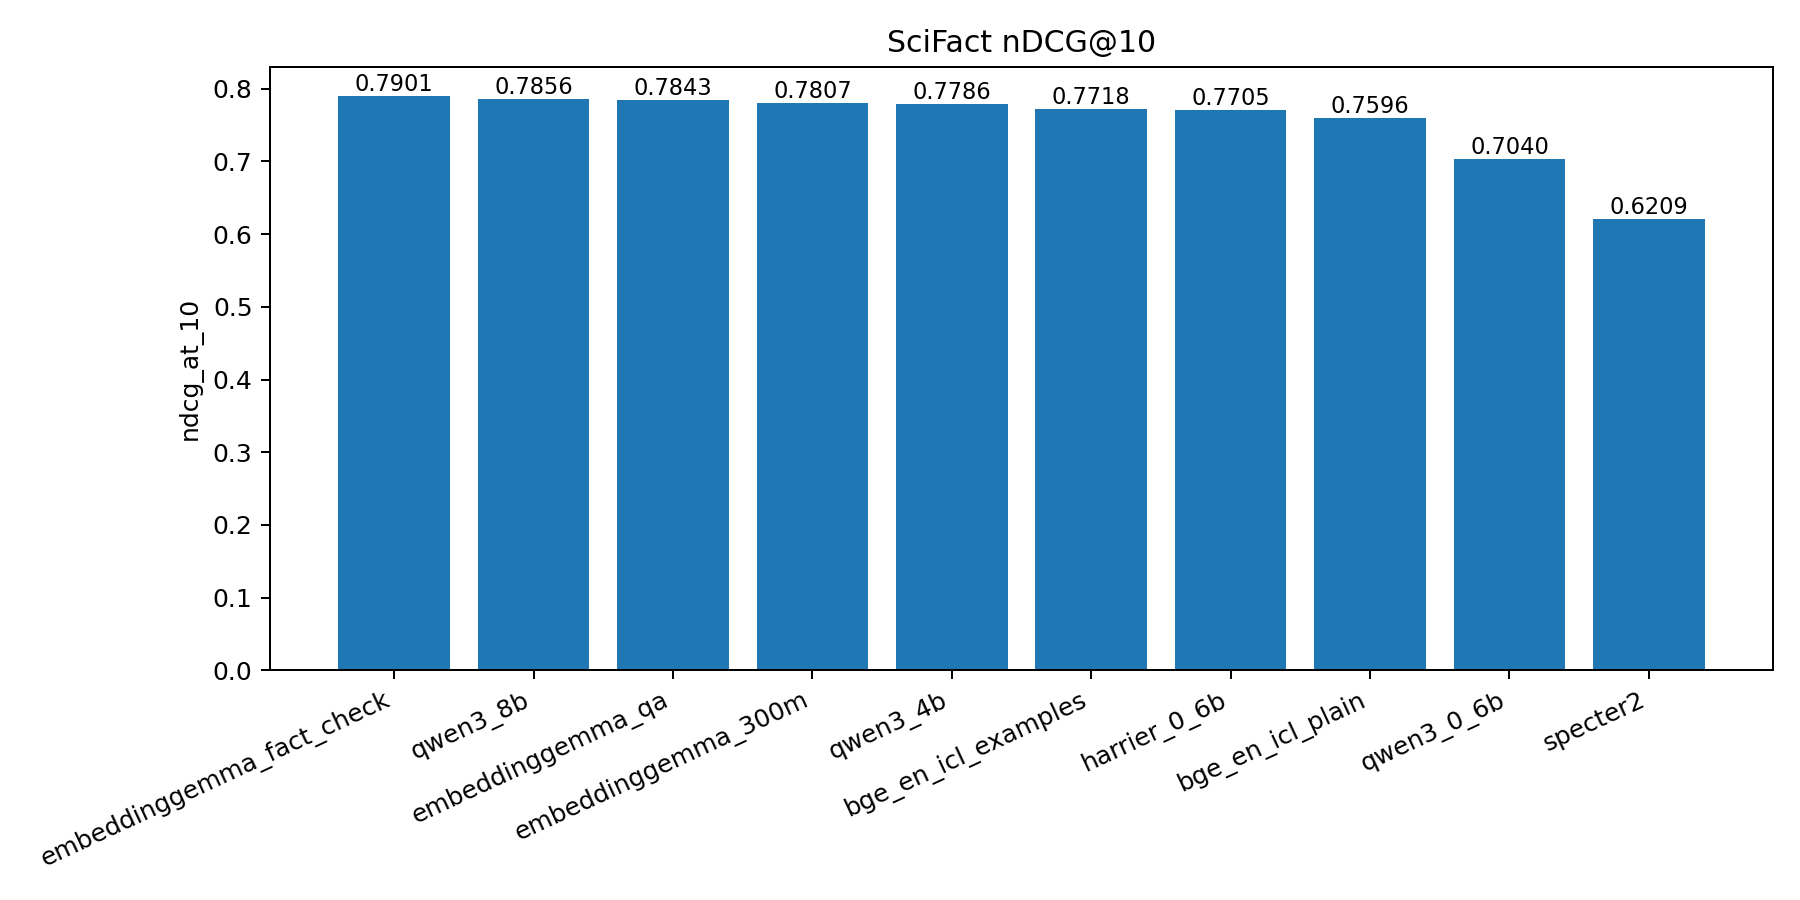

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/mrr_at_10.png


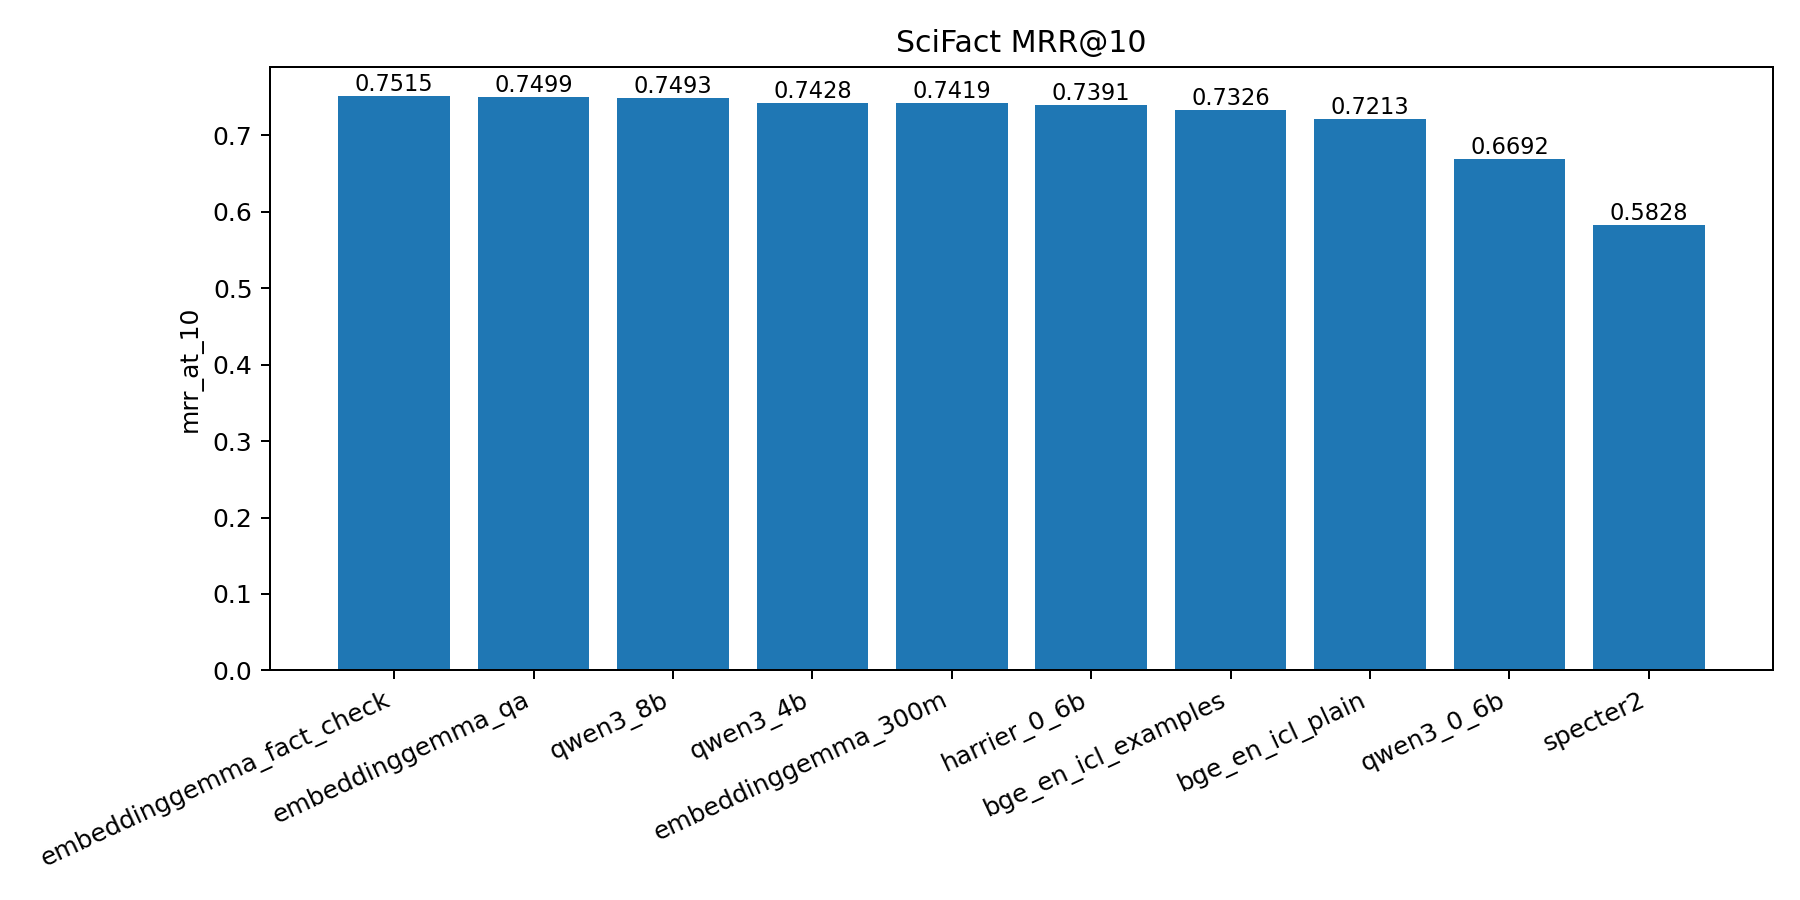

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/map_at_10.png


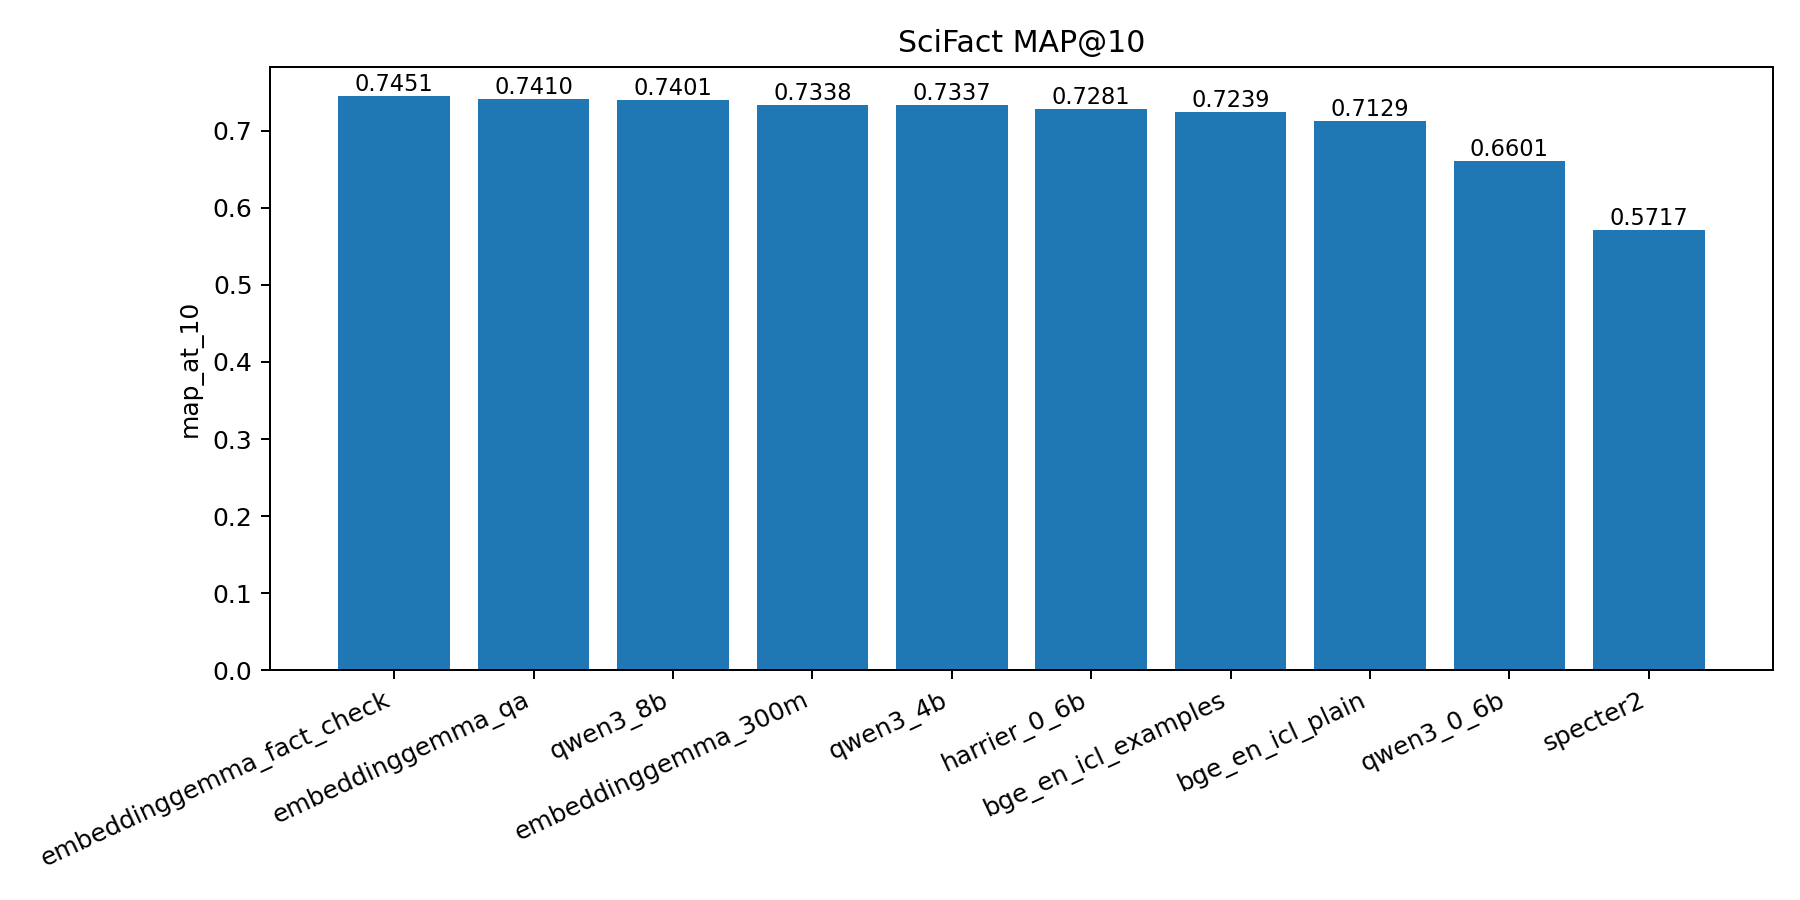

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/recall_at_100.png


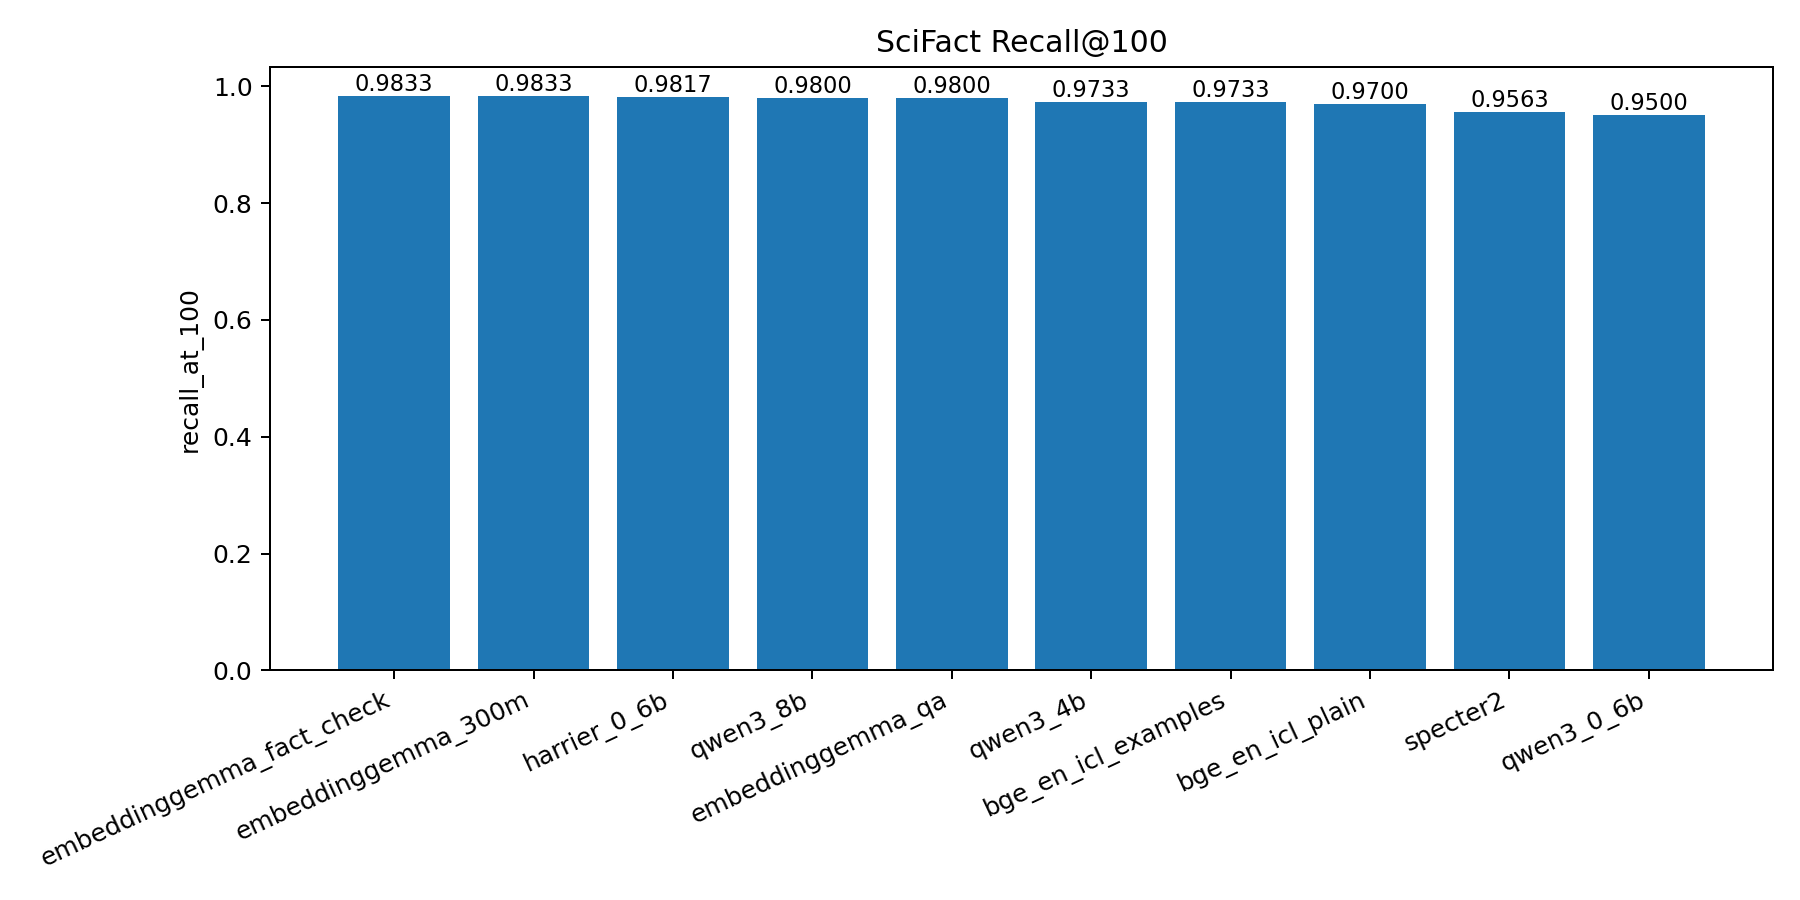

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/runtime_seconds.png


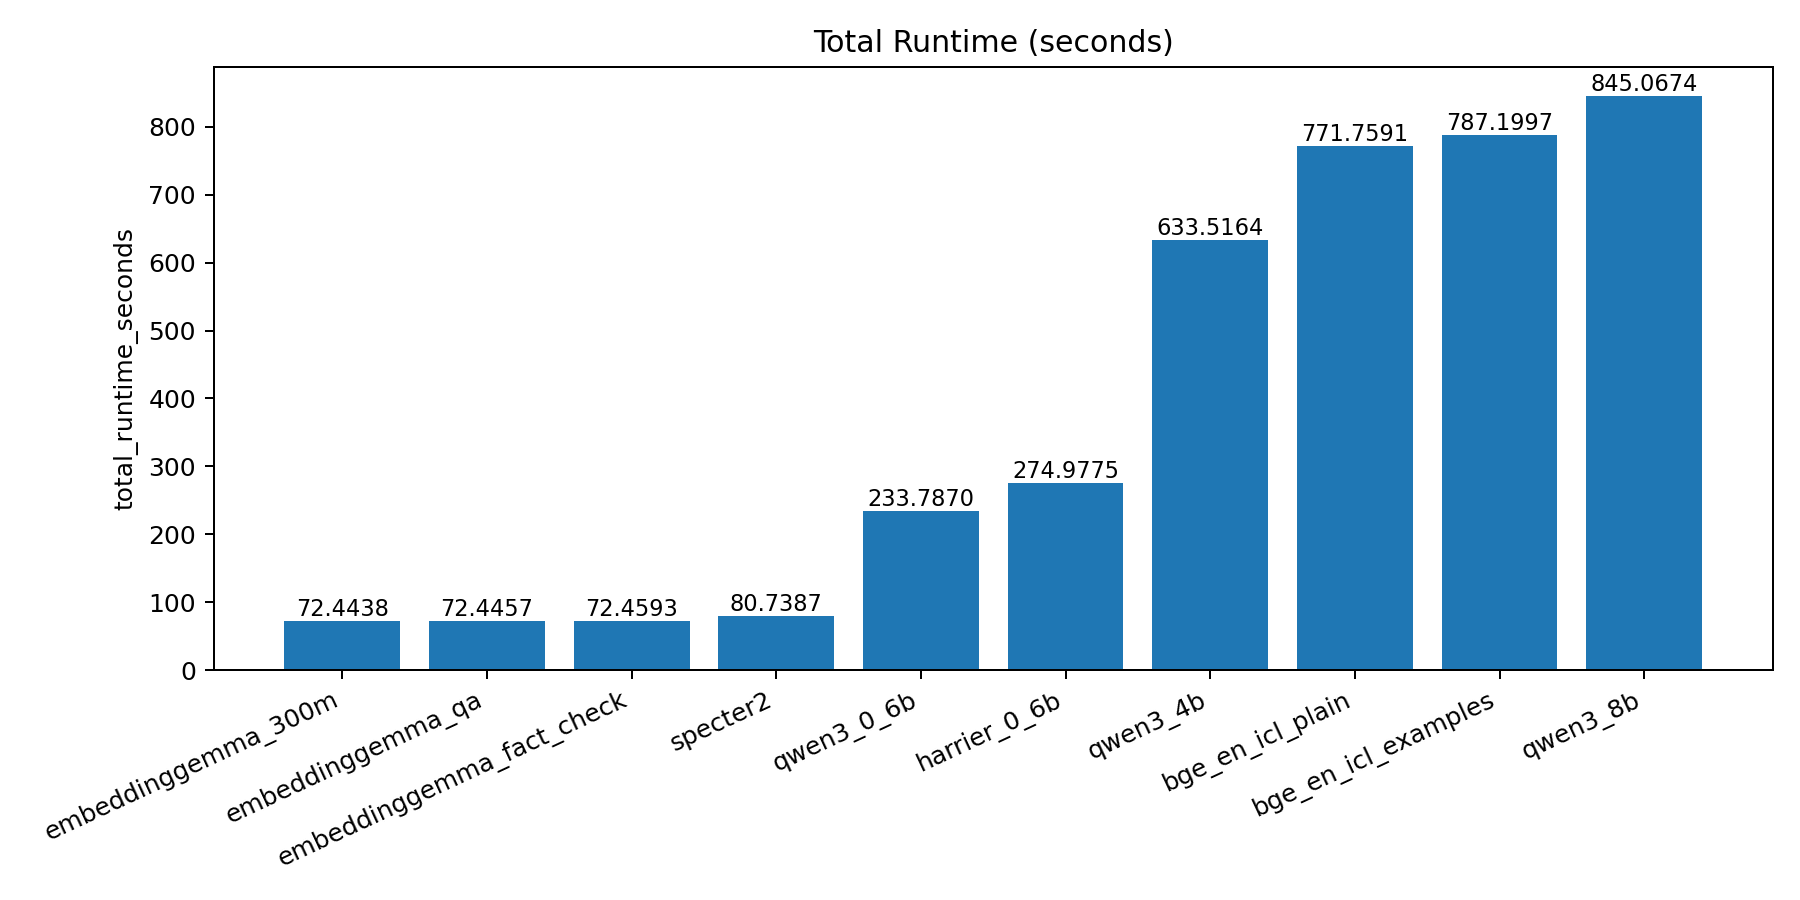

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/avg_query_end_to_end_latency_ms.png


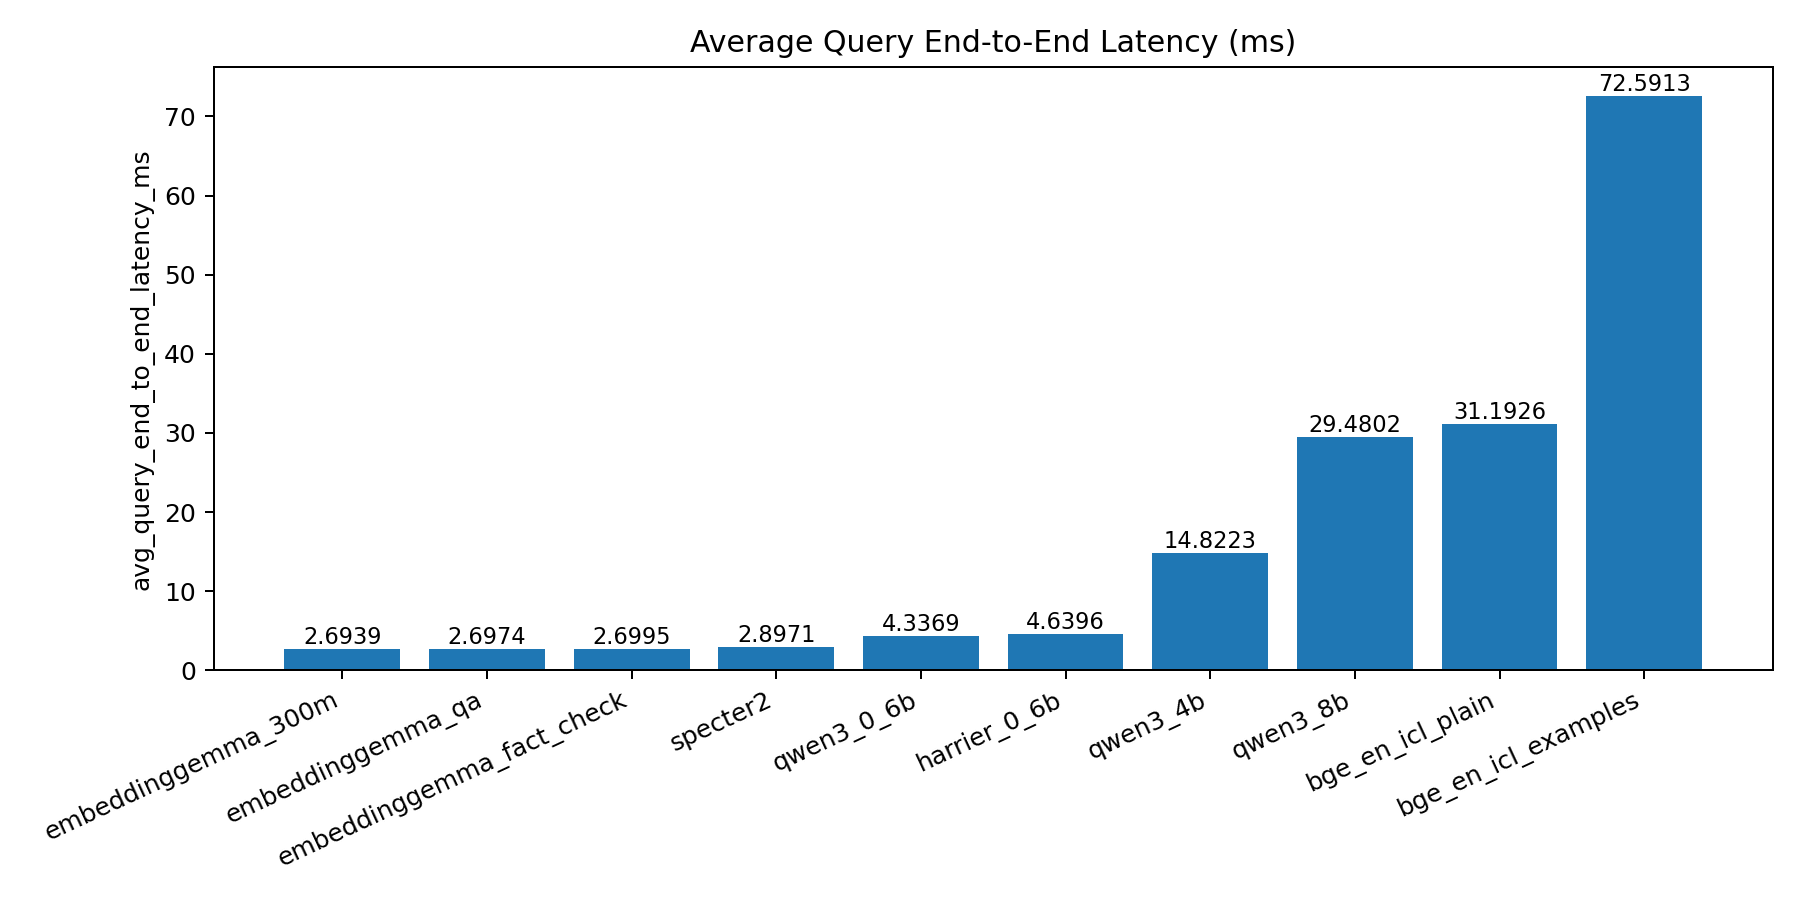

benchmarks/scifact/results/colab_scifact_20260428_225430/plots/ndcg_vs_avg_query_latency.png


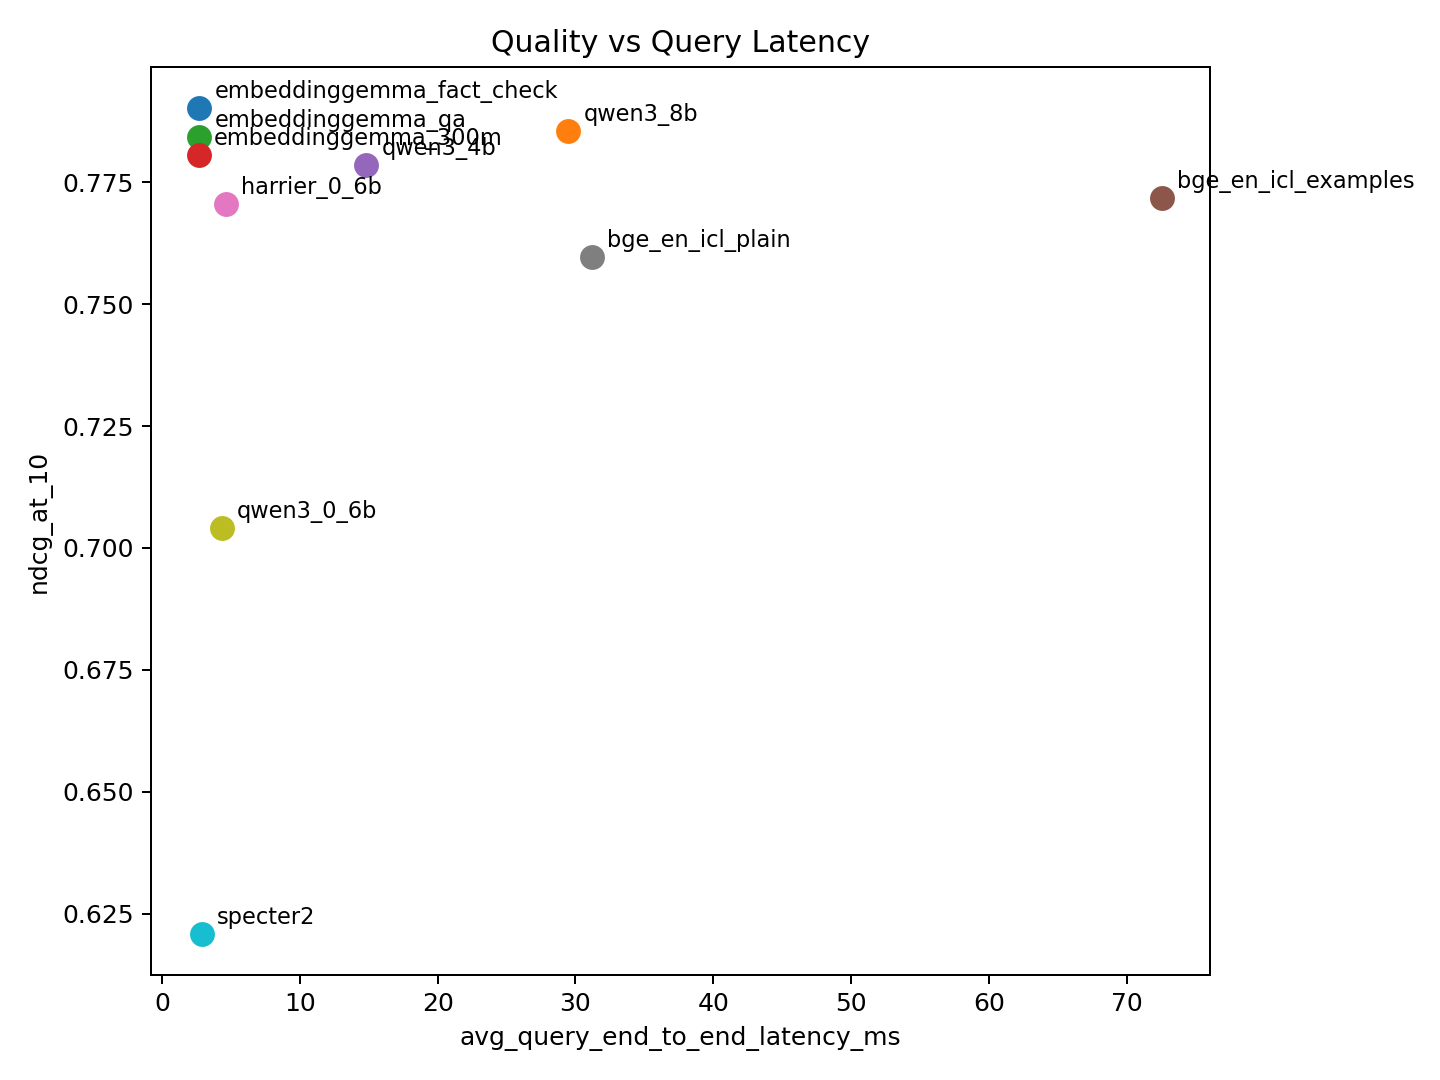

In [10]:
from IPython.display import Image, display

plots_dir = OUTPUT_DIR / "plots"
for name in ["ndcg_at_10.png", "mrr_at_10.png", "map_at_10.png", "recall_at_100.png", "runtime_seconds.png", "avg_query_end_to_end_latency_ms.png", "ndcg_vs_avg_query_latency.png"]:
    path = plots_dir / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


In [ ]:
# Inspect a specific model log after a failure.
MODEL_TO_INSPECT = MODELS[5]
log_path = OUTPUT_DIR / MODEL_TO_INSPECT / "run.log"
if log_path.exists():
    print(log_path)
    print(log_path.read_text()[-12000:])
else:
    print(f"No log found for {MODEL_TO_INSPECT}")

In [ ]:
# Rerun a single model with a lower batch size if needed.
# Example:
# BATCH_SIZE_OVERRIDES['qwen3_8b'] = 1
# run_one_model('qwen3_8b')

In [11]:
# Optional: zip the aggregate directory for download from Colab.
!zip -r "{OUTPUT_DIR}.zip" "{OUTPUT_DIR}"

  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/summary.csv (deflated 47%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/summary.json (deflated 55%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/rankings/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/rankings/qwen3_0_6b.csv (deflated 69%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/REPORT.md (deflated 55%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/config.json (deflated 32%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b/qwen3_0_6b_status.json (deflated 58%)
  adding: benchmarks/scifact/results/colab_scifact_20260428_225430/qwen3_0_6b